# Tutorial 1 - the fiducial model: DIB $\lambda$6614 in a mock binary spectrum

`MCMC-RVSD` fits **all epochs of a multi-epoch spectrum simultaneously**. The stellar lines
move with the orbital radial velocity (RV) while the DIB stays at its rest wavelength, so the
two components can be separated. This is the fiducial case of the paper:

| quantity | value |
|---|---|
| epochs / sampling | 24 epochs, $R=7500$ (0.12 $\rm\AA$ per pixel) |
| SNR | 200 per pixel |
| RV span | $-67$ to $+58\ \mathrm{km\,s^{-1}}$ |
| stellar line | Fe I at $6613.82\,\rm\AA$ (Gaussian) |
| DIB | Gaussian, centre $6613.66\,\rm\AA$, depth $0.049$, $\sigma=0.545\,\rm\AA$ |
| free parameters | 6 (3 stellar + 3 DIB), flat priors |

The likelihood adds the flux uncertainty induced by the RV error,
$\sigma_{\rm tot}^2=\sigma_{\rm flux}^2+[\,\mathrm{d}f/\mathrm{d}\lambda\cdot\lambda\,
\sigma_{RV}/c\,]^2$, so a large RV error is propagated into the fitted parameters instead of
being ignored.

The precomputed chain is loaded by default; set `RERUN = True` to run the sampler yourself
(48 walkers, 1500 burn-in, 5000 production steps).

In [1]:
%matplotlib inline
import json, sys, time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

try:                                     # installed with `pip install -e .`
    import mcmc_rvsd
except ImportError:                      # or run straight from a clone
    sys.path.insert(0, str(Path.cwd().parent / 'src'))
    import mcmc_rvsd
from mcmc_rvsd import SpectralModel, StellarLine, DIB, run_mcmc, plotting
from mcmc_rvsd.io import load_result, load_mock

ROOT = Path.cwd().parent if Path.cwd().name == 'examples' else Path.cwd()
FIG = ROOT / 'docs' / 'figures'
FIG.mkdir(parents=True, exist_ok=True)
RERUN = False             # set to True to redo the MCMC yourself (a few minutes)
print('mcmc_rvsd', mcmc_rvsd.__version__, '|',
      'running from a repository clone' if (ROOT / 'data').is_dir() else 'running from an installed package')

mcmc_rvsd 0.1.0 | running from a repository clone


## 1. The mock data and the input decomposition

24 epochs | 46 pixels | RV span -66.7 to 58.2 km/s
SpectralModel(stellar_lines=[FeI@6613.8250], dib=gaussian, n_params=6)


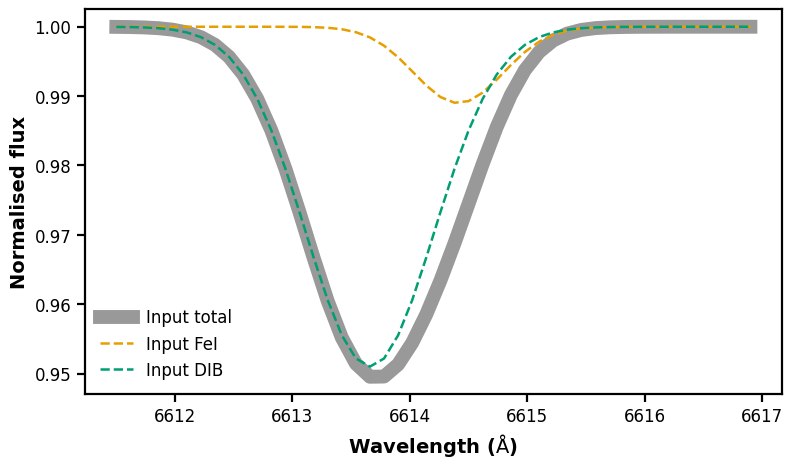

In [2]:
d = load_mock(ROOT / 'data/mock/mock_6614_gaussian.npz')
wave, flux, err = d['wave_analysis'], d['fluxs'], d['y_errs']
rvs, rv_err = d['rv_obs'], d['rv_err']
star, dib = d['stellar_truth'].item(), d['dib_truth'].item()
print(f'{flux.shape[0]} epochs | {wave.size} pixels | RV span {rvs.min():.1f} to {rvs.max():.1f} km/s')

model = SpectralModel(stellar_lines=[StellarLine('FeI', star['center'])],
                      dib=DIB(profile='gaussian'))
ptrue = model.initial_guess(stars=[[star['center'], star['strength'], star['sigma']]],
                            dib=[dib['center'], dib['strength'], dib['sigma']])
print(model)
plotting.plot_decomposition(wave, rvs[0], model, ptrue,
                            out=str(FIG / 'nb01_decomposition.png'))
plt.show()

The dashed curves are the two input components (stellar line and DIB) at the first epoch; the
thick grey band underneath is their product, i.e. the input total spectrum that the sampler has
to recover.

## 2. Run (or load) the MCMC

In [3]:
name = 'mock_6614_gaussian'
if RERUN:
    p0 = model.initial_guess(dib=[6613.66, 0.05, 0.55])
    res = run_mcmc(model, wave, flux, err, rvs, rv_err, p0=p0,
                   snrs=np.full(len(rvs), 200.0), seed=42)
    res.save(ROOT / f'examples/results/{name}.npz', thin=10)
else:
    res = load_result(ROOT / f'examples/results/{name}.npz')
print('quality label:', res.label, '| autocorrelation time:', np.round(res.tau, 1))

quality label: Success | autocorrelation time: [58.8 63.6 61.1 58.2 58.2 60.4]


## 3. Posterior summary and the deviation from the input values

In [4]:
print(res.summary())
print()
print(f'{"parameter":>14} {"fit":>12} {"truth":>12} {"dev (sigma)":>12}')
dev = (res.pfit - ptrue) / res.perr
for name, value, true, d in zip(model.param_names, res.pfit, ptrue, dev):
    print(f'{name:>14} {value:12.5f} {true:12.5f} {d:+12.2f}')

       parameter          value          +/-
----------------------------------------------
      lambda_FeI     6613.82505      0.02213
           A_FeI        0.01066      0.00061
       sigma_FeI        0.35274      0.02289
      lambda_DIB     6613.64882      0.00592
           A_DIB        0.04926      0.00047
       sigma_DIB        0.54885      0.00620
----------------------------------------------
lnL = -528.32 | AIC = 1068.64 | BIC = 1098.68
tau = [58.8 63.6 61.1 58.2 58.2 60.4] | label = Success
walkers = 48 | burn-in = 1500 | production = 5000

     parameter          fit        truth  dev (sigma)
    lambda_FeI   6613.82505   6613.82500        +0.00
         A_FeI      0.01066      0.01100        -0.55
     sigma_FeI      0.35274      0.38000        -1.19
    lambda_DIB   6613.64882   6613.66000        -1.89
         A_DIB      0.04926      0.04900        +0.56
     sigma_DIB      0.54885      0.54500        +0.62


Each parameter is recovered within a fraction of its own posterior error: the deviation column is
the difference from the input value in units of the posterior $1\sigma$ error. Values below
$\sim2\sigma$ mean the algorithm is unbiased for this setup.

## 4. Posterior distributions

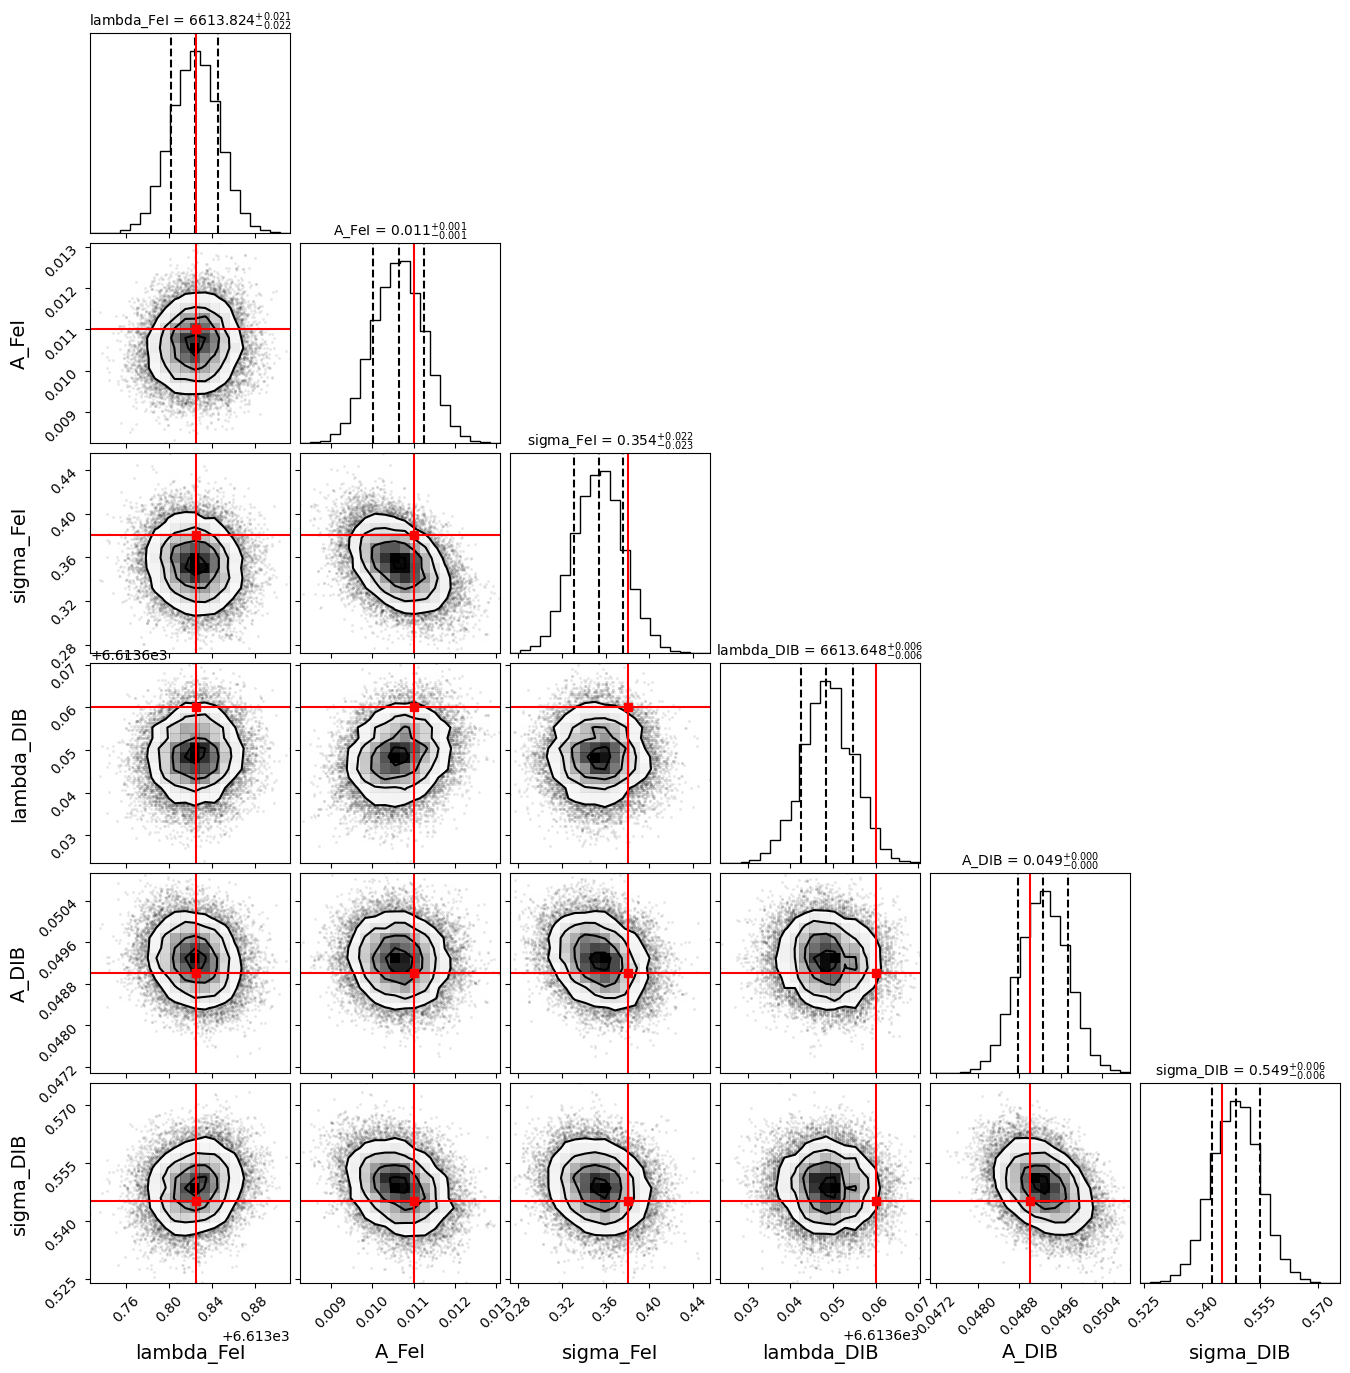

In [5]:
plotting.plot_corner(res.samples, model.param_names, truths=ptrue,
                     out=str(FIG / 'nb01_corner.png'))
plt.show()

## 5. Fit to the individual epochs

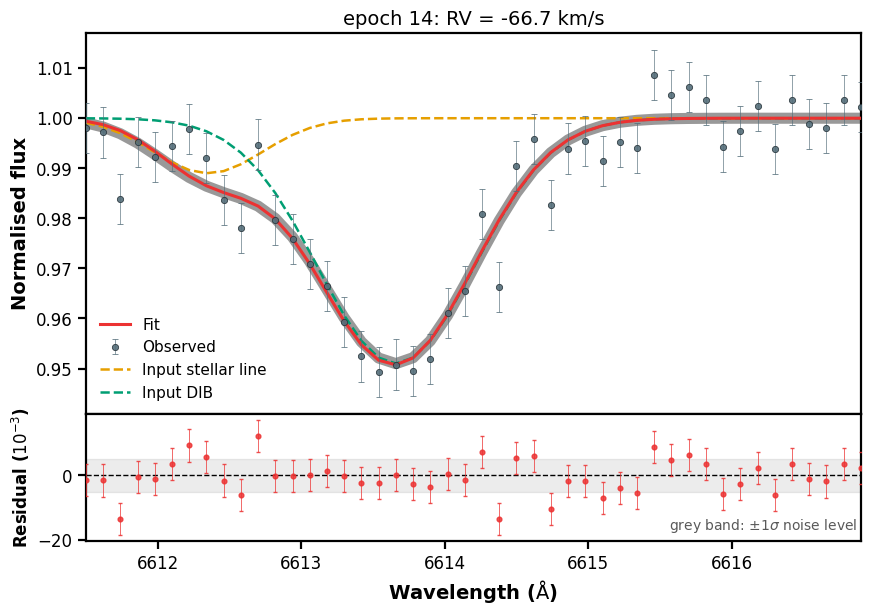

In [6]:
i = int(np.argmax(np.abs(rvs)))          # the epoch with the largest |RV|
plotting.plot_spectrum_fit(wave, flux, err, rvs, model, res.pfit, epoch=i, ptrue=ptrue,
                           title=f'epoch {i}: RV = {rvs[i]:+.1f} km/s',
                           out=str(FIG / 'nb01_fit.png'))
plt.show()

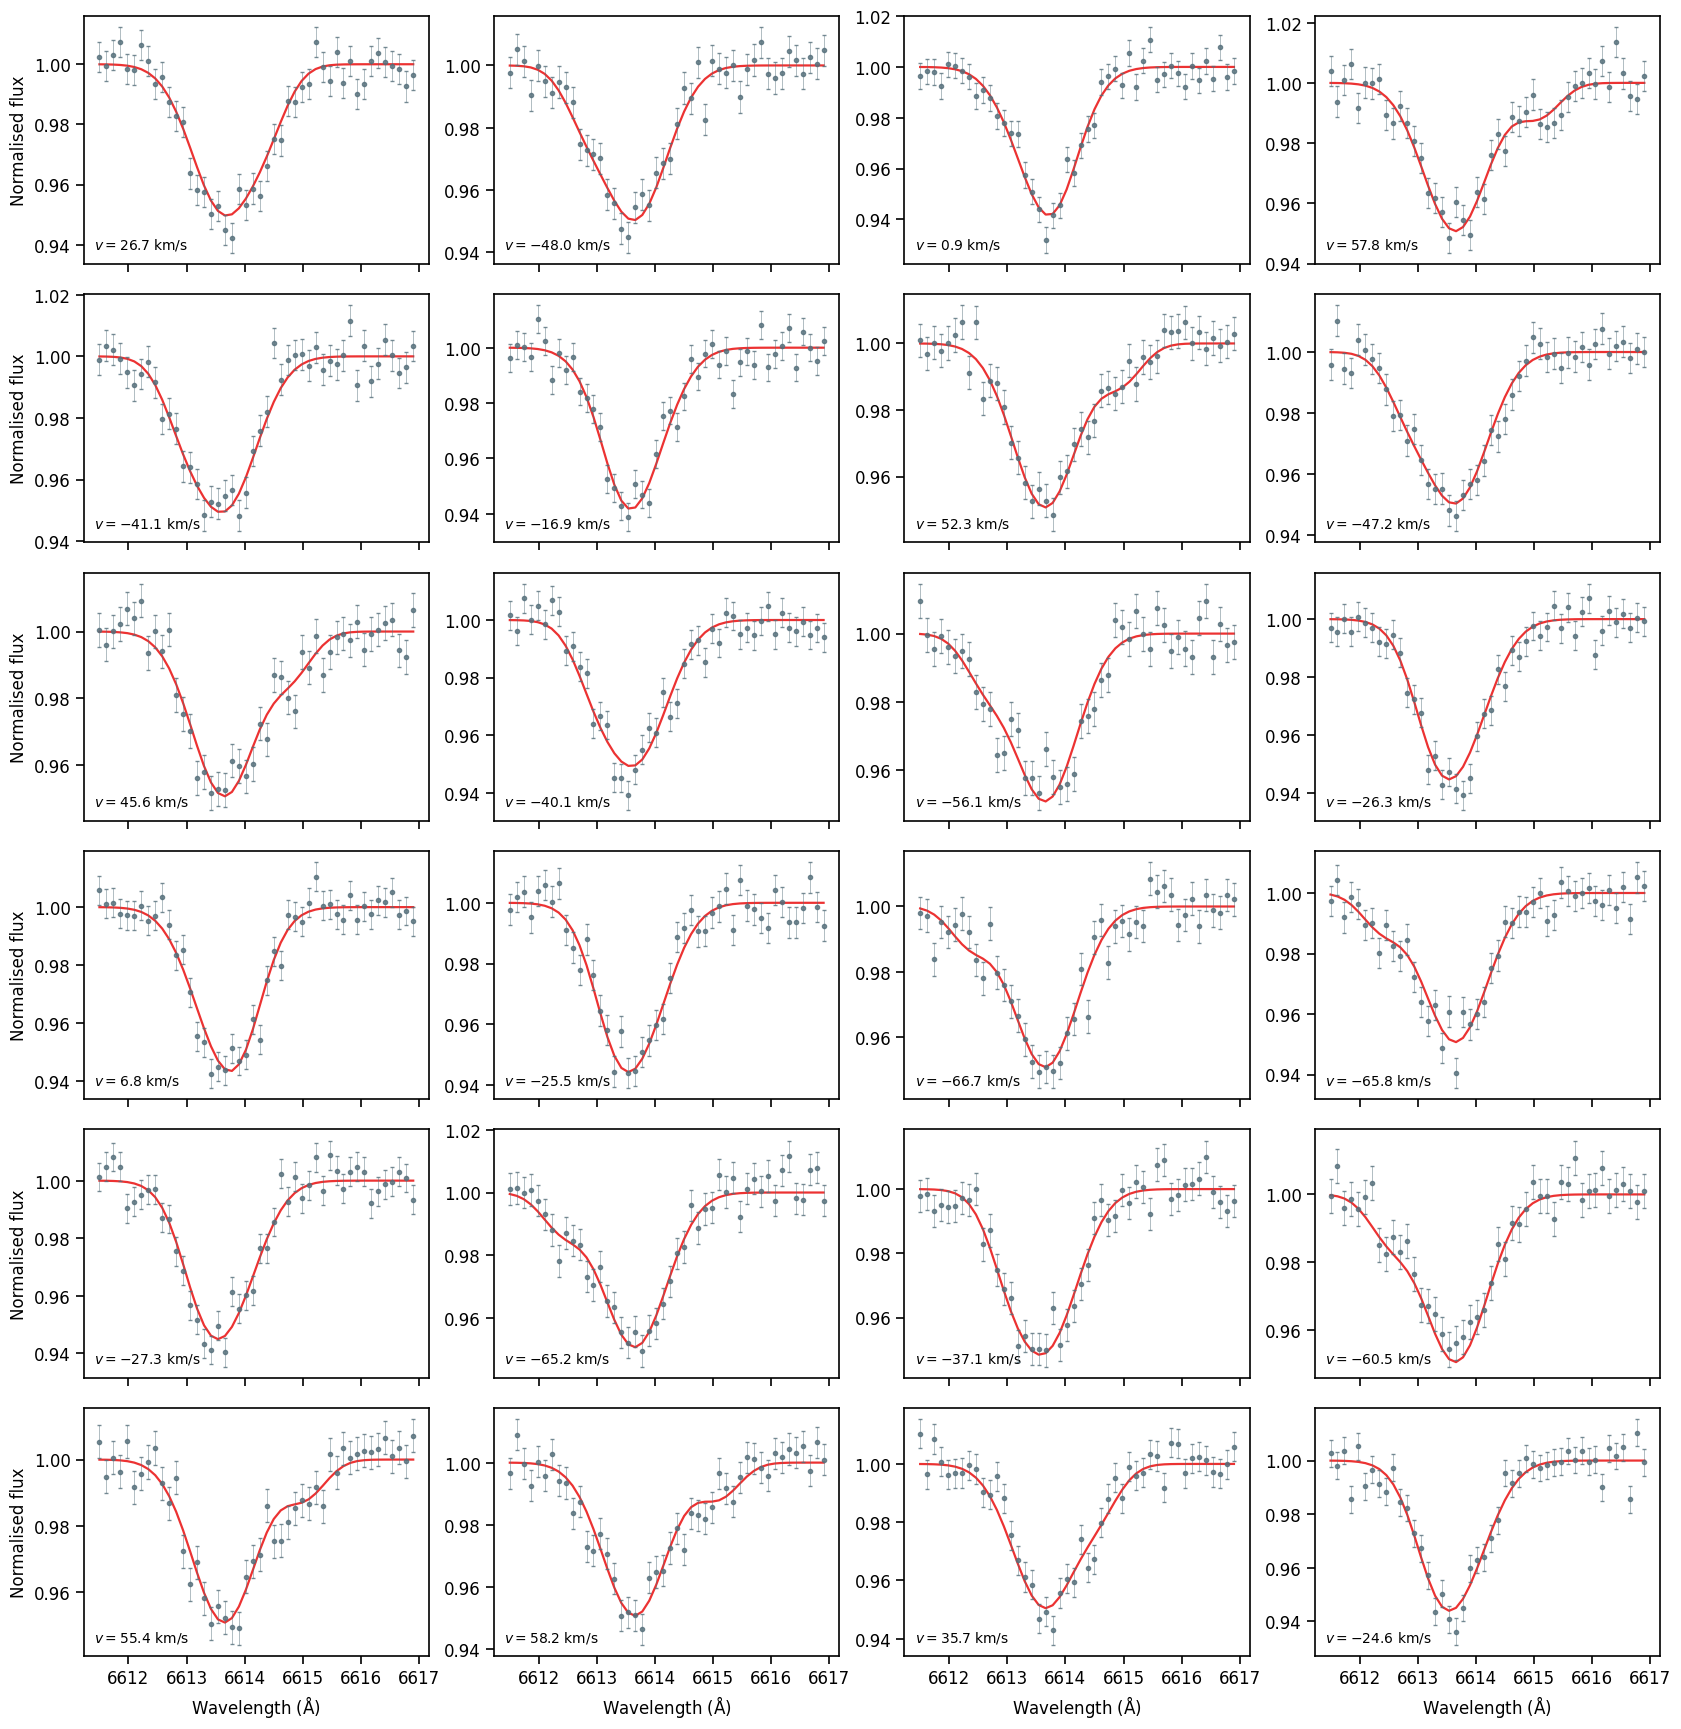

In [7]:
plotting.plot_all_epochs(wave, flux, err, rvs, model, res.pfit, ncols=4,
                         out=str(FIG / 'nb01_epochs.png'))
plt.show()

The stellar line moves from panel to panel while the DIB absorption stays at the same
wavelength - that wavelength stability is what allows the sampler to separate the two.

## What to take away

* six parameters (one stellar line + one Gaussian DIB) are enough for an isolated DIB with a
  single contaminating stellar line;
* the RV-uncertainty term matters: without it the quoted errors are too small;
* the posterior deviations are a direct, per-parameter check of the method on mock data.

Next: [02 - multiple stellar lines](02_multi_stellar_lines.ipynb) shows what happens when more
than one stellar line falls into the fitting window.